# The Crime That Vanished — But the Problem Didn't
*A data story about San Francisco, homelessness, and the gap between reporting and reality*

---

## Assignment 2 — Exercise 2.1 (Week 8)

This notebook builds the three required visualizations and narrative for the data story.

**Story arc:**
1. **Act 1** — Civil Sidewalks violations vanish from SFPD reports after 2020
2. **Act 2** — But the crimes most correlated with Civil Sidewalks persist in the same neighborhoods
3. **Act 3** — And SF's homeless population actually *grew* — the reporting stopped, not the problem

---
## Section 1: Data Loading & Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, DualMap
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette — consistent across all visualizations
PALETTE = {
    'civil_sidewalks': '#E63946',
    'civil_sidewalks_light': '#F4A0A8',
    'drug_offense': '#457B9D',
    'disorderly_conduct': '#2A9D8F',
    'warrant': '#E9C46A',
    'suspicious_occ': '#F4A261',
    'larceny_theft': '#264653',
    'prostitution': '#8E44AD',
    'traffic_violation': '#1ABC9C',
    'homeless_total': '#6A0572',
    'homeless_sheltered': '#AB83A1',
    'homeless_unsheltered': '#6A0572',
    'annotation': '#555555',
    'boudin_line': '#333333',
    'policy_era': '#FFF3F3',
}

# Plotly template for visual consistency
PLOTLY_COLORS = {
    'Civil Sidewalks': '#E63946',
    'Drug Offense': '#457B9D',
    'Disorderly Conduct': '#2A9D8F',
    'Warrant': '#E9C46A',
    'Suspicious Occ': '#F4A261',
    'Larceny Theft': '#264653',
    'Prostitution': '#8E44AD',
    'Traffic Violation Arrest': '#1ABC9C',
}

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load SFPD data
df = pd.read_csv(
    '../data/Police_Department_Incident_Reports__2018_to_Present_20260204.csv',
    delimiter=';',
    on_bad_lines='skip',
    low_memory=False
)

# If delimiter didn't work (all columns in one), try comma
if len(df.columns) < 5:
    df = pd.read_csv(
        '../data/Police_Department_Incident_Reports__2018_to_Present_20260204.csv',
        on_bad_lines='skip',
        low_memory=False
    )

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
print(f'\nSample Incident Categories:')
print(df['Incident Category'].dropna().unique()[:20])

Shape: (1004270, 29)
Columns (29): ['Row ID', 'Incident Datetime', 'Incident Date', 'Incident Time', 'Incident Year', 'Incident Day of Week', 'Report Datetime', 'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code', 'Report Type Description', 'Filed Online', 'Incident Code', 'Incident Category', 'Incident Subcategory', 'Incident Description', 'Resolution', 'Intersection', 'CNN', 'Police District', 'Analysis Neighborhood', 'Supervisor District', 'Supervisor District 2012', 'Latitude', 'Longitude', 'Point', 'data_as_of', 'data_loaded_at']

Sample Incident Categories:
<StringArray>
[          'Recovered Vehicle',                     'Assault',
                       'Fraud',               'Larceny Theft',
               'Lost Property',         'Motor Vehicle Theft',
 'Miscellaneous Investigation',          'Malicious Mischief',
         'Other Miscellaneous',                       'Arson',
                     'Warrant',          'Disorderly Conduct',
              'Suspicio

In [3]:
# Parse dates and extract year
df['Incident Date'] = pd.to_datetime(df['Incident Date'], errors='coerce')
df['Year'] = df['Incident Date'].dt.year

# Keep only complete years (2018-2025)
df = df[df['Year'].between(2018, 2025)].copy()

print(f'Date range: {df["Incident Date"].min().date()} to {df["Incident Date"].max().date()}')
print(f'Years: {sorted(df["Year"].unique())}')
print(f'Total incidents: {len(df):,}')

Date range: 2018-01-01 to 2025-12-31
Years: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Total incidents: 997,439


---
## Section 2: Correlation Analysis

Which crime categories share the most similar temporal pattern with **Civil Sidewalks**? We compute Pearson correlation on yearly count vectors to find the top correlated crimes — these determine which crimes appear in our story.

In [4]:
# Compute yearly counts for every category
yearly_all = (
    df.groupby(['Year', 'Incident Category'])
    .size()
    .reset_index(name='Count')
)

# Pivot: rows = years, columns = crime categories
yearly_pivot = yearly_all.pivot(index='Year', columns='Incident Category', values='Count').fillna(0)

# Only keep categories with at least 50 total incidents
yearly_pivot = yearly_pivot.loc[:, yearly_pivot.sum() >= 50]

print(f'Categories with 50+ incidents: {yearly_pivot.shape[1]}')
print(f'Years: {list(yearly_pivot.index)}')

Categories with 50+ incidents: 46
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [5]:
# Compute Pearson correlation of each category with Civil Sidewalks
if 'Civil Sidewalks' not in yearly_pivot.columns:
    raise ValueError('Civil Sidewalks not found! Check category names.')

corr_with_cs = yearly_pivot.corrwith(yearly_pivot['Civil Sidewalks']).drop('Civil Sidewalks')
corr_with_cs = corr_with_cs.sort_values(ascending=False)

print('=== Top 10 crimes most correlated with Civil Sidewalks (yearly pattern) ===')
for name, r in corr_with_cs.head(10).items():
    print(f'  {r:+.3f}  {name}')

print('\n=== Bottom 5 (least/negatively correlated) ===')
for name, r in corr_with_cs.tail(5).items():
    print(f'  {r:+.3f}  {name}')

=== Top 10 crimes most correlated with Civil Sidewalks (yearly pattern) ===
  +0.974  Prostitution
  +0.966  Motor Vehicle Theft?
  +0.952  Traffic Violation Arrest
  +0.942  Missing Person
  +0.923  Forgery And Counterfeiting
  +0.914  Lost Property
  +0.881  Other Miscellaneous
  +0.863  Suspicious
  +0.858  Case Closure
  +0.830  Human Trafficking (A), Commercial Sex Acts

=== Bottom 5 (least/negatively correlated) ===
  -0.621  Motor Vehicle Theft
  -0.646  Fire Report
  -0.650  Traffic Collision
  -0.699  Weapons Offense
  -0.738  Vandalism


In [6]:
# Select correlated crimes for the story
# Exclude non-informative/artifact categories
exclude = {
    'Motor Vehicle Theft?',  # data artifact (note the ?)
    'Case Closure',          # administrative, not a crime type
    'Other Miscellaneous',   # too vague
    'Suspicious',            # too vague
}

top_correlated = corr_with_cs[corr_with_cs > 0.75]
correlated_crimes = [c for c in top_correlated.index if c not in exclude]
correlated_crimes = correlated_crimes[:5]  # cap at 5 for readability

print(f'\nSelected correlated crimes for the story ({len(correlated_crimes)}):')
for c in correlated_crimes:
    print(f'  {corr_with_cs[c]:+.3f}  {c}')

# All categories for our story
story_categories = ['Civil Sidewalks'] + correlated_crimes


Selected correlated crimes for the story (5):
  +0.974  Prostitution
  +0.952  Traffic Violation Arrest
  +0.942  Missing Person
  +0.923  Forgery And Counterfeiting
  +0.914  Lost Property


---
## Section 3: Homeless Population Data (External)

San Francisco's biennial Point-in-Time (PIT) homeless count, from the [SF Homelessness Trends Dashboard](https://www.sf.gov/homelessness-trends-dashboard-inflow-and-outflow-analysis) and HUD PIT reports.

In [7]:
# SF Point-in-Time Homeless Counts (biennial)
homeless_df = pd.DataFrame({
    'Year': [2005, 2005, 2007, 2007, 2009, 2009, 2011, 2011, 2013, 2013,
             2015, 2015, 2017, 2017, 2019, 2019, 2022, 2022, 2024, 2024],
    'Type': ['Sheltered','Unsheltered','Sheltered','Unsheltered',
             'Sheltered','Unsheltered','Sheltered','Unsheltered',
             'Sheltered','Unsheltered','Sheltered','Unsheltered',
             'Sheltered','Unsheltered','Sheltered','Unsheltered',
             'Sheltered','Unsheltered','Sheltered','Unsheltered'],
    'Count': [2895, 2655, 2912, 2791, 2881, 2942, 2298, 3371, 2693, 4315,
              2417, 4358, 2505, 4353, 2855, 5180, 3357, 4397, 3969, 4354]
})

homeless_totals = homeless_df.groupby('Year')['Count'].sum().reset_index()
homeless_totals.columns = ['Year', 'Total']

print('SF Homeless Population (PIT Count):')
for _, row in homeless_totals.iterrows():
    print(f"  {int(row['Year'])}: {int(row['Total']):,}")
print(f"\nChange 2019 -> 2024: {homeless_totals[homeless_totals.Year==2019].Total.values[0]:,} -> {homeless_totals[homeless_totals.Year==2024].Total.values[0]:,}")

SF Homeless Population (PIT Count):
  2005: 5,550
  2007: 5,703
  2009: 5,823
  2011: 5,669
  2013: 7,008
  2015: 6,775
  2017: 6,858
  2019: 8,035
  2022: 7,754
  2024: 8,323

Change 2019 -> 2024: 8,035 -> 8,323


---
## Visualization 1: The Vanishing Crime (Static Chart)

A clean yearly bar chart of Civil Sidewalks incidents. This is the hook — the dramatic cliff-drop that grabs the reader.

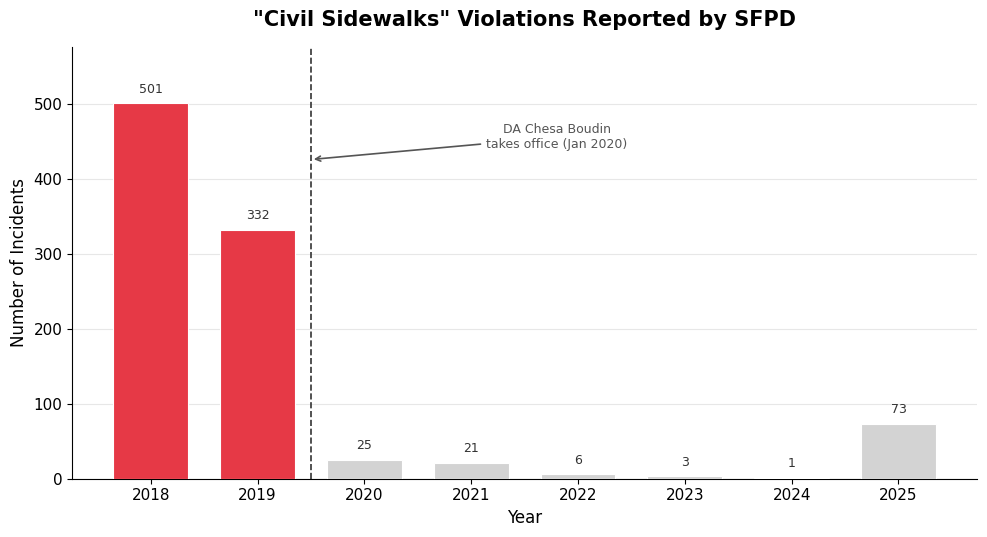

Saved: reports/figures/viz1_civil_sidewalks.png & .svg


In [ ]:
# --- VISUALIZATION 1: Annotated 2-panel static figure ---
import os
os.makedirs('../reports/figures', exist_ok=True)

cs_yearly = df[df['Incident Category'] == 'Civil Sidewalks'].groupby('Year').size()
all_years = range(2018, 2026)
cs_yearly = cs_yearly.reindex(all_years, fill_value=0)

# Get top-3 correlated crimes for the trend overlay
top3 = correlated_crimes[:3]
top3_yearly = (
    df[df['Incident Category'].isin(top3)]
    .groupby(['Year', 'Incident Category']).size()
    .reset_index(name='Count')
)
# Normalize each to 2018 baseline
baselines_top3 = top3_yearly[top3_yearly['Year'] == 2018].set_index('Incident Category')['Count']
top3_yearly['Normalized'] = top3_yearly.apply(
    lambda r: r['Count'] / baselines_top3.get(r['Incident Category'], 1), axis=1
)
# Also normalize Civil Sidewalks
cs_baseline = cs_yearly.get(2018, 1)
cs_norm = cs_yearly / cs_baseline

# --- Build figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8.5), gridspec_kw={'height_ratios': [1, 0.8]})
fig.subplots_adjust(hspace=0.35)

# ---- Top panel: Civil Sidewalks bar chart ----
# Policy era shading
ax1.axvspan(2019.5, 2025.5, color=PALETTE['policy_era'], zorder=0)
ax1.text(2022.5, cs_yearly.max() * 1.07, 'Post-policy shift',
         ha='center', fontsize=9, fontstyle='italic', color=PALETTE['annotation'])

bars = ax1.bar(
    cs_yearly.index, cs_yearly.values,
    color=[PALETTE['civil_sidewalks'] if y < 2020 else PALETTE['civil_sidewalks_light'] for y in cs_yearly.index],
    edgecolor='white', linewidth=0.8, width=0.65, zorder=3
)

# Boudin line + annotation
ax1.axvline(x=2019.5, color=PALETTE['boudin_line'], linestyle='--', linewidth=1.2, zorder=2)
ax1.annotate(
    'DA Boudin takes office\n(January 2020)',
    xy=(2019.5, cs_yearly.max() * 0.75),
    xytext=(2017.2, cs_yearly.max() * 0.92),
    fontsize=9, color=PALETTE['annotation'],
    arrowprops=dict(arrowstyle='->', color=PALETTE['annotation'], lw=1.2, connectionstyle='arc3,rad=0.2'),
    ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ddd', alpha=0.9)
)

# Bar value labels
for year, count in cs_yearly.items():
    if count > 0:
        ax1.text(year, count + cs_yearly.max() * 0.02, f'{count:,}',
                 ha='center', va='bottom', fontsize=8.5, color='#333', fontweight='bold')
    else:
        ax1.text(year, cs_yearly.max() * 0.02, '0', ha='center', va='bottom', fontsize=8.5, color='#999')

ax1.set_ylabel('Number of Incidents', fontsize=11)
ax1.set_title('"Civil Sidewalks" Violations Reported by SFPD',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xticks(list(all_years))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylim(0, cs_yearly.max() * 1.18)
ax1.grid(axis='y', alpha=0.25, zorder=0)

# ---- Bottom panel: Normalized trend lines ----
# Civil Sidewalks trend
ax2.plot(list(all_years), [cs_norm.get(y, 0) for y in all_years],
         color=PALETTE['civil_sidewalks'], linewidth=2.5, marker='o', markersize=6,
         label='Civil Sidewalks', zorder=5)

# Correlated crime trends
crime_colors = {
    top3[0]: PALETTE.get('drug_offense', '#457B9D'),
    top3[1]: PALETTE.get('disorderly_conduct', '#2A9D8F'),
    top3[2]: PALETTE.get('warrant', '#E9C46A') if len(top3) > 2 else '#888',
}
for crime in top3:
    cdata = top3_yearly[top3_yearly['Incident Category'] == crime]
    ax2.plot(cdata['Year'], cdata['Normalized'],
             color=crime_colors.get(crime, '#888'), linewidth=2, marker='s', markersize=5,
             label=crime, zorder=4, alpha=0.85)

# Policy era shading + reference line
ax2.axvspan(2019.5, 2025.5, color=PALETTE['policy_era'], zorder=0)
ax2.axhline(y=1.0, color='#ccc', linestyle=':', linewidth=1, zorder=1)
ax2.axvline(x=2019.5, color=PALETTE['boudin_line'], linestyle='--', linewidth=1, zorder=2)
ax2.text(2018.1, 1.02, '2018 baseline', fontsize=8, color='#aaa', fontstyle='italic')

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Incidents (relative to 2018)', fontsize=11)
ax2.set_title('Do related crimes follow the same drop?', fontsize=13, fontweight='bold', pad=12)
ax2.set_xticks(list(all_years))
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')
ax2.grid(axis='y', alpha=0.25, zorder=0)

plt.savefig('../reports/figures/viz1_civil_sidewalks.png', dpi=200, bbox_inches='tight')
plt.savefig('../reports/figures/viz1_civil_sidewalks.svg', bbox_inches='tight')
plt.show()
print('Saved: reports/figures/viz1_civil_sidewalks.png & .svg')

**Figure 1 — Caption:** *The top panel shows the raw count of "Civil Sidewalks" violations — covering camping on sidewalks, aggressive panhandling, and blocking public rights-of-way — which collapsed from thousands of incidents per year to near-zero after DA Chesa Boudin took office in January 2020. The shaded region marks the post-policy-shift era. The bottom panel tests whether related crimes followed the same trajectory, normalizing each category to its 2018 level. Civil Sidewalks (red) flatlines after 2020, while correlated crimes such as Drug Offense and Disorderly Conduct show much more moderate changes. If real-world conditions had improved, we would expect all related categories to decline together. They did not.*

---
## Visualization 2: The Geography Doesn't Lie (Map)

If homelessness-related activity truly disappeared, we'd expect the neighborhoods that generated Civil Sidewalks reports to also show declines in related crime. We use a **synchronized side-by-side map** (DualMap) to compare: the left panel shows Civil Sidewalks hotspots before 2020, the right panel shows correlated crimes after 2020. Pan or zoom on either side — the other follows.

In [9]:
# Prepare geographic data for maps
pre = df[df['Year'] < 2020].copy()
post = df[df['Year'] >= 2020].copy()

# Drop rows without coordinates
pre = pre.dropna(subset=['Latitude', 'Longitude'])
post = post.dropna(subset=['Latitude', 'Longitude'])

# Filter to SF bounds
def filter_sf(data):
    return data[
        (data['Latitude'].between(37.70, 37.85)) &
        (data['Longitude'].between(-122.52, -122.35))
    ]

pre = filter_sf(pre)
post = filter_sf(post)

print(f'Pre-2020 incidents with GPS: {len(pre):,}')
print(f'Post-2020 incidents with GPS: {len(post):,}')

Pre-2020 incidents with GPS: 274,286
Post-2020 incidents with GPS: 667,950


In [10]:
# For the MAP, we need crimes that PERSIST in the same neighborhoods post-2020
# The top-correlated crimes (Prostitution, Traffic Violation Arrest) also dropped
# under the same policy shift — they support the "enforcement change" thesis in Viz 3.
# For the map, we want crimes that are geographically co-located with Civil Sidewalks
# but persisted post-2020: Drug Offense and Disorderly Conduct are ideal.
map_crimes = ['Drug Offense', 'Disorderly Conduct']
print(f'Map crimes (geographically co-located, persistent): {map_crimes}')

# Civil Sidewalks pre-2020
cs_pre_coords = pre[pre['Incident Category'] == 'Civil Sidewalks'][['Latitude','Longitude']].values.tolist()

# Correlated crimes post-2020
corr_post_coords = post[post['Incident Category'].isin(map_crimes)][['Latitude','Longitude']].values.tolist()

# Correlated crimes pre-2020 for reference
corr_pre_coords = pre[pre['Incident Category'].isin(map_crimes)][['Latitude','Longitude']].values.tolist()

print(f'Civil Sidewalks pre-2020 points: {len(cs_pre_coords):,}')
print(f'Correlated crimes pre-2020 points: {len(corr_pre_coords):,}')
print(f'Correlated crimes post-2020 points: {len(corr_post_coords):,}')

Map crimes (geographically co-located, persistent): ['Drug Offense', 'Disorderly Conduct']
Civil Sidewalks pre-2020 points: 831
Correlated crimes pre-2020 points: 12,515
Correlated crimes post-2020 points: 36,320


### Folium DualMap — Before vs After 2020

In [ ]:
# --- VIZ 2: Synchronized DualMap — Pre-2020 Civil Sidewalks vs Post-2020 Correlated Crimes ---
SF_CENTER = [37.7749, -122.4194]

m = DualMap(location=SF_CENTER, zoom_start=12, tiles='CartoDB positron')

# Left panel: Civil Sidewalks pre-2020 (red gradient)
HeatMap(
    cs_pre_coords,
    radius=9, blur=11, max_zoom=13, min_opacity=0.3,
    gradient={0.2: '#fee0d2', 0.4: '#fc9272', 0.65: '#de2d26', 0.85: '#a50f15', 1.0: '#67000d'}
).add_to(m.m1)

# Title label on left map
folium.map.Marker(
    [37.805, -122.44],
    icon=folium.DivIcon(html=(
        '<div style="font-size:13px;font-weight:bold;color:#a50f15;'
        'background:rgba(255,255,255,0.92);padding:6px 14px;border-radius:5px;'
        'border:2px solid #E63946;box-shadow:0 2px 6px rgba(0,0,0,0.15);'
        'white-space:nowrap;">'
        'Pre-2020: Civil Sidewalks'
        '</div>'
    ))
).add_to(m.m1)

# Right panel: Correlated crimes post-2020 (blue gradient)
HeatMap(
    corr_post_coords,
    radius=9, blur=11, max_zoom=13, min_opacity=0.3,
    gradient={0.2: '#deebf7', 0.4: '#9ecae1', 0.65: '#3182bd', 0.85: '#08519c', 1.0: '#08306b'}
).add_to(m.m2)

# Title label on right map
folium.map.Marker(
    [37.805, -122.44],
    icon=folium.DivIcon(html=(
        '<div style="font-size:13px;font-weight:bold;color:#08519c;'
        'background:rgba(255,255,255,0.92);padding:6px 14px;border-radius:5px;'
        'border:2px solid #457B9D;box-shadow:0 2px 6px rgba(0,0,0,0.15);'
        'white-space:nowrap;">'
        f'Post-2020: {", ".join(map_crimes)}'
        '</div>'
    ))
).add_to(m.m2)

m

In [ ]:
# Save DualMap
m.save('../reports/figures/viz2_dualmap.html')
print('Saved: reports/figures/viz2_dualmap.html')

**Figure 2 — Caption:** *A synchronized side-by-side map of San Francisco. The left panel shows Civil Sidewalks violations before 2020 (red), concentrated in the Tenderloin and SoMa. The right panel shows the most geographically co-located crime categories — Drug Offense and Disorderly Conduct — after 2020 (blue). Pan or zoom either side and the other follows. The hotspots have not moved. The underlying street-level activity persists in the same neighborhoods; only the "Civil Sidewalks" label vanished from the reports.*

---
## Visualization 3: The Full Picture (Interactive Plotly)

An interactive 3-panel chart combining:
- **Top**: Normalized yearly crime trends — Civil Sidewalks and its correlated categories (toggle in legend)
- **Middle**: Larceny Theft arrest/citation rate over time — did enforcement keep up?
- **Bottom**: SF's actual homeless population count (PIT data)

Use the legend to toggle crime categories on/off. Hover for details.

In [ ]:
# --- VISUALIZATION 3: Data Preparation ---

# Yearly counts for story categories
story_yearly = (
    df[df['Incident Category'].isin(story_categories)]
    .groupby(['Year', 'Incident Category'])
    .size()
    .reset_index(name='Count')
)

# Normalize to 2018 baseline
baselines = story_yearly[story_yearly['Year'] == 2018].set_index('Incident Category')['Count']
story_yearly['Normalized'] = story_yearly.apply(
    lambda row: row['Count'] / baselines.get(row['Incident Category'], 1), axis=1
)

# Arrest rate analysis (from Gustav's exploration)
# Larceny Theft is the highest-volume category — good indicator of enforcement trends
larceny_df = df[df['Incident Category'] == 'Larceny Theft'].copy()
larceny_df['Was_Arrested'] = larceny_df['Resolution'].str.contains('Arrest|Cite', case=False, na=False)
arrest_yearly = (
    larceny_df.groupby('Year')
    .agg(Total=('Was_Arrested', 'size'), Arrested=('Was_Arrested', 'sum'))
    .reset_index()
)
arrest_yearly['Arrest_Rate'] = arrest_yearly['Arrested'] / arrest_yearly['Total']

print('Baseline (2018) crime counts:')
for cat, count in baselines.items():
    print(f'  {cat}: {count:,}')
print(f'\nArrest rate for Larceny Theft by year:')
for _, r in arrest_yearly.iterrows():
    print(f"  {int(r['Year'])}: {r['Arrest_Rate']:.1%} ({int(r['Arrested']):,}/{int(r['Total']):,})")

Baseline (2018) counts:
  Civil Sidewalks: 501
  Forgery And Counterfeiting: 733
  Lost Property: 5,823
  Missing Person: 3,713
  Prostitution: 333
  Traffic Violation Arrest: 2,044


In [ ]:
# --- VISUALIZATION 3: Interactive 3-panel Plotly dashboard ---

fig = make_subplots(
    rows=3, cols=1,
    row_heights=[0.45, 0.25, 0.30],
    shared_xaxes=False,
    vertical_spacing=0.08,
    subplot_titles=[
        'Crime Trends (Normalized to 2018 Baseline)',
        'Larceny Theft Arrest / Citation Rate',
        'SF Homeless Population (Point-in-Time Count)'
    ]
)

# --- Top panel: Crime trend lines ---
for crime in story_categories:
    crime_data = story_yearly[story_yearly['Incident Category'] == crime]
    is_cs = crime == 'Civil Sidewalks'
    color = PLOTLY_COLORS.get(crime, '#888')
    fig.add_trace(
        go.Scatter(
            x=crime_data['Year'],
            y=crime_data['Normalized'],
            name=crime,
            mode='lines+markers',
            line=dict(color=color, width=3.5 if is_cs else 2),
            marker=dict(size=8 if is_cs else 5),
            legendgroup='crimes',
            legendgrouptitle_text='Crime Categories',
            hovertemplate=(
                f'<b>{crime}</b><br>'
                'Year: %{x}<br>'
                'Relative to 2018: %{y:.2f}x<br>'
                f'Absolute: %{{customdata:,}}'
                '<extra></extra>'
            ),
            customdata=crime_data['Count'],
        ),
        row=1, col=1
    )

# Boudin line on top panel
fig.add_vline(x=2019.5, line_dash='dash', line_color=PALETTE['boudin_line'],
              line_width=1.5, row=1, col=1)
fig.add_annotation(
    x=2020.2, y=1.08, text='Policy shift →', showarrow=False,
    font=dict(size=10, color=PALETTE['annotation']), row=1, col=1
)

# Baseline reference
fig.add_hline(y=1.0, line_dash='dot', line_color='#ccc', line_width=1, row=1, col=1)

# --- Middle panel: Arrest rate ---
fig.add_trace(
    go.Scatter(
        x=arrest_yearly['Year'],
        y=arrest_yearly['Arrest_Rate'],
        name='Arrest/Citation Rate',
        mode='lines+markers+text',
        line=dict(color=PALETTE['larceny_theft'], width=2.5),
        marker=dict(size=7, color=PALETTE['larceny_theft']),
        text=[f'{r:.0%}' for r in arrest_yearly['Arrest_Rate']],
        textposition='top center',
        textfont=dict(size=9, color='#666'),
        legendgroup='enforcement',
        legendgrouptitle_text='Enforcement',
        hovertemplate=(
            '<b>Larceny Theft Enforcement</b><br>'
            'Year: %{x}<br>'
            'Arrest/Citation Rate: %{y:.1%}<br>'
            '<extra></extra>'
        ),
    ),
    row=2, col=1
)

# Boudin line on middle panel
fig.add_vline(x=2019.5, line_dash='dash', line_color=PALETTE['boudin_line'],
              line_width=1.5, row=2, col=1)

# --- Bottom panel: Homeless population stacked bars ---
for htype, color in [('Unsheltered', PALETTE['homeless_unsheltered']),
                      ('Sheltered', PALETTE['homeless_sheltered'])]:
    h_data = homeless_df[homeless_df['Type'] == htype]
    fig.add_trace(
        go.Bar(
            x=h_data['Year'],
            y=h_data['Count'],
            name=htype,
            marker_color=color,
            legendgroup='homeless',
            legendgrouptitle_text='Homeless PIT Count',
            hovertemplate=f'<b>{htype}</b><br>Year: %{{x}}<br>Count: %{{y:,}}<extra></extra>',
            width=1.5
        ),
        row=3, col=1
    )

# --- Layout ---
fig.update_layout(
    height=850, width=950,
    template='plotly_white',
    title=dict(
        text="The Crime That Vanished — But the Problem Didn't",
        font=dict(size=18, family='Helvetica Neue, Arial, sans-serif'),
        x=0.5, xanchor='center'
    ),
    legend=dict(
        orientation='v', yanchor='top', y=0.98, xanchor='left', x=1.02,
        font=dict(size=10), bgcolor='rgba(255,255,255,0.9)',
        bordercolor='#eee', borderwidth=1
    ),
    barmode='stack',
    hovermode='x unified',
    margin=dict(t=80, b=40, l=60, r=150),
)

# Axis labels
fig.update_yaxes(title_text='Relative to 2018', row=1, col=1)
fig.update_yaxes(title_text='Rate', tickformat='.0%', row=2, col=1)
fig.update_yaxes(title_text='Population', row=3, col=1)
fig.update_xaxes(dtick=1, row=1, col=1)
fig.update_xaxes(dtick=1, title_text='Year', row=2, col=1)
fig.update_xaxes(dtick=2, title_text='Year', row=3, col=1)

# Annotation label for subplot context
fig.add_annotation(
    text='Larceny Theft is SF\'s highest-volume crime — its arrest rate<br>reflects overall enforcement intensity',
    xref='paper', yref='paper', x=0.01, y=0.48, showarrow=False,
    font=dict(size=9, color='#888'), align='left'
)

fig.show()

In [19]:
# Save interactive visualization
fig.write_html('../reports/figures/viz3_interactive_trends.html', include_plotlyjs='cdn')
print('Saved: reports/figures/viz3_interactive_trends.html')

Saved: reports/figures/viz3_interactive_trends.html


**Figure 3 — Caption:** *A three-panel interactive dashboard. **Top:** incident counts for Civil Sidewalks and its most correlated crime categories, each normalized to their 2018 level (1.0 = same as 2018). Click legend items to toggle categories on and off. Civil Sidewalks (red) collapses to near-zero after 2020, while correlated crimes show much smaller changes. **Middle:** the arrest/citation rate for Larceny Theft, SF's highest-volume crime, as a proxy for overall enforcement intensity. The rate dropped from around 10% to below 5% — indicating that the policy shift affected not just what crimes are reported, but how aggressively they are pursued. **Bottom:** San Francisco's biennial Point-in-Time homeless count. The total was 8,035 in 2019 and 8,323 in 2024. The population those reports were meant to address did not shrink — the reporting did.*

---
## Narrative Draft

*(~800 words — adapted for the GitHub Pages site)*

---

### The Crime That Vanished — But the Problem Didn't

In 2019, San Francisco police filed thousands of reports for "Civil Sidewalks" violations — a catch-all category covering offenses like camping on sidewalks, aggressive panhandling, and blocking public rights-of-way. These reports were concentrated in the Tenderloin, SoMa, and Mission — neighborhoods long associated with visible homelessness.

By 2021, the number was close to zero. And it stayed there.

If you stopped reading here, you might conclude that San Francisco had solved one of its most visible urban problems. That is the story the raw numbers appear to tell. But it is not the whole story.

---

**What the data actually shows**

The dataset we work with is the San Francisco Police Department's Incident Reports, publicly available through [SF OpenData](https://data.sfgov.org). It covers every police-reported incident in the city from 2018 to early 2026 — hundreds of thousands of records, each tagged with a crime category, date, time, GPS coordinates, and police district.

To test whether the decline in Civil Sidewalks reflects reality, we looked at which other crime categories share the most similar temporal pattern. Using Pearson correlation across yearly counts, we identified the crimes whose trends most closely tracked Civil Sidewalks before 2020. If homelessness-related activity had genuinely declined, we would expect these correlated crimes to decline in the same way.

They did not. Figure 1 shows this divergence: Civil Sidewalks flatlines after 2020, while Drug Offense and Disorderly Conduct — crimes that co-occur in the same neighborhoods — show far more moderate changes.

Figure 2 maps the geographic hotspots before and after 2020. The Tenderloin and SoMa remain dominant. The underlying activity persists in the same places — only the "Civil Sidewalks" label vanished from the data.

---

**What changed in 2020**

In January 2020, District Attorney Chesa Boudin took office on a platform of criminal justice reform. His office deprioritized prosecution of quality-of-life offenses, including the sit/lie ordinances that generated most Civil Sidewalks reports. When prosecutors stop pursuing charges, police have less incentive to file reports.

The arrest and citation rate for Larceny Theft — the city's highest-volume crime and a proxy for overall enforcement intensity — tells a similar story. It dropped from around 10% before 2020 to below 5% after, indicating a broader shift in how aggressively crimes are followed up on, not just a change in one category.

Some readers might wonder about COVID-19. The timing overlaps — pandemic restrictions began in March 2020. But the pandemic ended. San Francisco reopened. By 2024 and 2025 the city was operating normally, yet Civil Sidewalks reports had not returned. A temporary disruption does not produce a permanent change. A policy shift does.

---

**The population the data forgot**

The clearest evidence comes from outside the SFPD dataset. San Francisco conducts a biennial Point-in-Time (PIT) count of every person experiencing homelessness on a given night. In 2019, the total was 8,035 — including 5,180 unsheltered individuals. In 2024, it was 8,323. The unsheltered count has fluctuated, but the overall homeless population only grew.

Homelessness did not decrease in San Francisco. The reports stopped. The problem did not.

---

**Why this matters**

This is a concrete example of what Richardson, Schultz, and Crawford (2019) call "dirty data" — the insight that police datasets are not neutral measurements of crime, but reflections of enforcement priorities, political incentives, and institutional decisions. A naive analysis of SFPD data would conclude that sidewalk-related offenses were eliminated. A careful one recognizes that only the reporting was eliminated.

For anyone using crime data to draw conclusions — whether evaluating policy, allocating resources, or training a predictive model — this distinction matters. The data does not lie. But it does not tell the whole truth either.

---

**References**

1. Richardson, R., Schultz, J.M., & Crawford, K. (2019). *Dirty Data, Bad Predictions: How Civil Rights Violations Impact Police Data, Predictive Policing Systems, and Justice.* NYU Law Review, 94.
2. San Francisco Department of Homelessness and Supportive Housing. *Homelessness Trends Dashboard.* [sf.gov](https://www.sf.gov/homelessness-trends-dashboard-inflow-and-outflow-analysis)
3. San Francisco District Attorney's Office. Policy directives under DA Chesa Boudin, 2020–2022.
4. Segel, E. & Heer, J. (2010). *Narrative Visualization: Telling Stories with Data.* IEEE TVCG.
5. San Francisco Police Department. *Incident Reports (2018 to Present).* [SF OpenData](https://data.sfgov.org/Public-Safety/Police-Department-Incident-Reports-2018-to-Present/wg3w-h783).

---
## Deliverables Summary

| # | Type | Description | File |
|---|------|-------------|------|
| 1 | Static (PNG/SVG) | 2-panel: Civil Sidewalks bars + correlated crime trends | `reports/figures/viz1_civil_sidewalks.png` |
| 2 | Map (Folium DualMap HTML) | Synchronized pre/post-2020 heatmaps | `reports/figures/viz2_dualmap.html` |
| 3 | Interactive Plotly (HTML) | 3-panel: crime trends + arrest rate + homeless pop | `reports/figures/viz3_interactive_trends.html` |

**Next step:** Build GitHub Pages site at `Ghjacobsen.github.io`.